# Pricing Monte Carlo di una call asiatica sull'EURO STOXX 50 con tasso di interesse stocastico

## Contesto e domanda quantitativa

Il caso riguarda la valutazione di una **call asiatica OTC a media aritmetica** sullo indice EURO STOXX 50, in cui sia il livello del sottostante sia il tasso nominale a breve termine evolvono in modo stocastico. La dinamica dell'indice è descritta da un moto browniano geometrico (GBM) con short rate stocastico e dividend yield continuo, mentre il tasso nominale segue un processo CIR che soddisfa la condizione di Feller. I due processi sono correlati tramite un coefficiente $\rho$.

La domanda quantitativa del caso è:

> **Qual è il valore corrente della call asiatica sull'EURO STOXX 50, stimato mediante simulazione Monte Carlo, quando il livello dell'indice e il tasso nominale evolvono congiuntamente in modo stocastico?**

La **variabile finale** oggetto della simulazione è il valore attualizzato del payoff ottenuto in ciascuno scenario, la cui media campionaria restituisce il prezzo Monte Carlo della call asiatica $\widehat V_M$.

L'**informazione disponibile** comprende: il valore iniziale dell'indice $S_0$ e del tasso $r_0$ (ancorati a osservazioni di mercato alla data del 27 luglio 2026), le proxy di mercato per il dividend yield $q$ e la volatilità $\sigma_S$, i parametri modellistici/didattici per il processo CIR ($\kappa_r$, $\theta_r$, $\sigma_r$) e la correlazione $\rho$, le specifiche contrattuali (strike $K$, scadenza $T$, fixing mensili) e i parametri di simulazione ($M$, $N$, $\Delta t$, seed).

---

## Quantità da stimare o calcolare

Le quantità richieste devono essere determinate nel seguente ordine operativo:

1. Media e deviazione standard simulate di $S_T$ e $r_T$
2. Media e deviazione standard simulate del prezzo medio $A_T$
3. Probabilità simulata di esercizio $\widehat{\mathbb P}(A_T>K)$
4. Valore medio del payoff non attualizzato $H_T$
5. Prezzo Monte Carlo della call asiatica $\widehat V_M$
6. Errore standard Monte Carlo e intervallo di confidenza al 95% del prezzo

---

## Output richiesti

### Tabelle

1. **Tabella dei parametri del caso**, distinguendo dati osservati, proxy di mercato e parametri didattici
2. **Tabella delle statistiche dei fattori e della media asiatica**, contenente media e deviazione standard di $S_T$, $r_T$ e $A_T$
3. **Tabella di sintesi del payoff e del pricing**, contenente probabilità di esercizio, payoff medio, prezzo Monte Carlo, errore standard e intervallo di confidenza al 95%
4. **Tabella di diagnostica Monte Carlo** per $M=1\,000,\ 5\,000,\ 10\,000,\ 50\,000$, riportando almeno prezzo stimato ed errore standard

### Grafici

1. Alcune traiettorie simulate dell'EURO STOXX 50, $S_t$
2. Alcune traiettorie simulate del tasso nominale $r_t$
3. Distribuzione simulata di $A_T$, con evidenza dello strike $K$
4. Distribuzione dei valori attualizzati $V^{(s)}$
5. Grafico di convergenza della stima Monte Carlo al crescere di $M$

---

## Controlli richiesti

Il notebook deve verificare esplicitamente che:

1. La correlazione empirica degli shock simulati sia coerente con il valore assegnato $\rho=-0,25$
2. Il processo simulato del sottostante soddisfi $S_t>0$
3. Eventuali valori negativi di $r_t$ prodotti dalla discretizzazione siano rilevati e documentati secondo la convenzione numerica adottata nel caso aula
4. Per ogni scenario valga $\min_jS_{t_j}\leq A_T\leq\max_jS_{t_j}$
5. Il payoff soddisfi sempre $H_T\geq0$ e sia nullo quando $A_T\leq K$
6. L'integrale del tasso sia costruito utilizzando i valori $r_{t_0},\ldots,r_{t_{N-1}}$ della stessa traiettoria e il fattore di sconto soddisfi $\widehat D^{(s)}(0,T)>0$
7. L'errore standard Monte Carlo diminuisca al crescere di $M$, in modo compatibile con l'ordine $1/\sqrt{M}$
8. Il prezzo sia sufficientemente stabile rispetto a una griglia temporale più fine
9. I risultati siano replicabili utilizzando il seed assegnato

---

**Nota:** La Scheda Caso costituisce la specifica vincolante del lavoro e non deve essere modificata.

# Scomposizione del notebook in tappe input-output

La proposta di 4-5 tappe macroscopiche cattura correttamente la logica di avanzamento del problema. Tuttavia, per rispettare i vincoli della Scheda Caso (che richiede output, tabelle e controlli molto specifici e disaccoppiati) e per rendere tracciabile il passaggio di dati da una fase alla successiva, è opportuno suddividerla in **5 tappe operative**, separando la generazione degli shock, la simulazione, il calcolo del payoff, l'attualizzazione e la diagnostica.

Di seguito la scomposizione dettagliata:

| Tappa | Input | Operazione | Output | Controllo | Uso successivo |
| :---: | --- | --- | --- | --- | --- |
| **1** | Parametri del caso, $M$, $N$, seed | Inizializzazione parametri. Generazione di $M \times N$ matrici di normali i.i.d. $Z_1, Z_2$. Applicazione della decomposizione di Cholesky per ottenere le matrici di shock correlati $Z_S, Z_r$ | Matrici $Z_S, Z_r$; <br>Tabella 1 (Parametri) | 1. Correlazione empirica campionaria tra $Z_S$ e $Z_r$ coerente con $\rho = -0,25$ | Alimentazione delle ESD di $r_t$ e $S_t$ nella Tappa 2 |
| **2** | $r_0, S_0$, parametri CIR e GBM, $\Delta t$, matrici $Z_S, Z_r$ | Ciclo di discretizzazione passo-per-passo: evoluzione $r_t$ (convenzione caso aula) ed $S_t$ (GBM con drift stocastico) | Matrici traiettorie $r_t [M \times 253]$, $S_t [M \times 253]$; <br>Grafici 1 e 2 (traiettorie campione); <br>Medie/DevStd $S_T, r_T$ (Tabella 2 parziale) | 2. $S_t > 0 \ \forall t$; <br>3. Rilevamento e gestione $r_t < 0$ | Estrazione fixing $S_{t_j}$ e griglia $r_{t_k}$ per Tappa 3 e 4 |
| **3** | Matrice $S_t$, $m=12$, $K$ | Selezione colonne $S_t$ ai passi 21, 42, ..., 252. Calcolo media aritmetica $A_T$. Calcolo payoff $H_T = \max(A_T - K, 0)$. Calcolo probabilità di esercizio | Vettori $A_T [M \times 1]$, $H_T [M \times 1]$; <br>$\widehat{\mathbb P}(A_T > K)$; <br>Grafico 3 (distribuzione $A_T$ e $K$); <br>Medie/DevStd $A_T$ (Tabella 2 completa) | 4. $\min_j S_{t_j} \leq A_T \leq \max_j S_{t_j}$; <br>5. $H_T \geq 0$ e nullo se $A_T \leq K$ | Payoff $H_T$ per l'attualizzazione nella Tappa 4 |
| **4** | Matrice $r_t$, $\Delta t$, Vettore $H_T$ | Approssimazione integrale di $r_t$ tramite somma di Riemann sinistra. Calcolo fattore di sconto $\widehat D(0,T)$. Calcolo valore attualizzato per scenario: $V^{(s)} = \widehat D \cdot H_T$ | Vettori $\widehat D(0,T) [M \times 1]$, $V^{(s)} [M \times 1]$; <br>Grafico 4 (distribuzione $V^{(s)}$) | 6. Integrale usa indici $k=0, \dots, N-1$ e $\widehat D(0,T) > 0$ | Vettore $V^{(s)}$ per aggregazione MC nella Tappa 5 |
| **5** | Vettore $V^{(s)}$, seed, parametri di simulazione | Calcolo stimatore MC $\widehat V_M$, deviazione standard campionaria, errore standard $SE$, IC 95%. Esecuzione simulazioni parziali ($M=1k, 5k, 10k$) e con griglia temporale più fine. | Prezzo $\widehat V_M$, $SE$, IC; <br>Tabella 3 (Sintesi payoff/pricing); <br>Tabella 4 (Diagnostica MC); <br>Grafico 5 (Convergenza stima MC) | 7. $SE$ diminuisce compatibilmente con $1/\sqrt{M}$; <br>8. Stabilità con griglia più fine; <br>9. Replicabilità con seed | Interpretazione conclusiva dei risultati |

## Tappa 1 — Inizializzazione parametri e generazione degli shock
### Cell Markdown

**Richiesta dello studente:**
Costruisci la Tappa 1. Bisogna inizializzare i parametri del caso, fissare il seed e generare le due matrici di shock casuali da usare poi per il sottostante e per il tasso. Vorrei anche costruire gli shock correlati con il valore di $\rho$ assegnato e controllare che la correlazione empirica ottenuta sia abbastanza vicina a $-0{,}25$. Mi sembra utile produrre già in questa tappa anche la tabella dei parametri del caso, distinguendo i diversi tipi di parametri come richiesto nella Scheda Caso. Per i risultati numerici e i controlli vorrei una presentazione attraverso **tabelle ben formattate**, non semplici blocchi di testo allineato.

**Sintesi logica degli output previsti:**
1.  **Tabella dei parametri:** Struttura formattata con le quattro colonne richieste (Componente, Parametro, Valore, Natura), con classificazione esplicita della natura di ciascun parametro.
2.  **Generazione degli shock:** Creazione delle matrici di shock indipendenti $Z_1$ e $Z_2$ e delle matrici di shock correlati $Z_S$ e $Z_r$, conformi alle dimensioni $M \times N$.
3.  **Tabella di controllo correlazione:** Verifica formattata che la correlazione empirica campionaria tra $Z_S$ e $Z_r$ sia coerente con il valore target $\rho = -0,25$.


In [8]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# ------------------------------------------------------------------
# 1. Inizializzazione parametri del caso
# ------------------------------------------------------------------
t0 = "27/07/2026"
S0 = 6286.35
K = 6300.0
T = 1.0
m = 12
q = 0.025
sigma_S = 0.18
r0 = 0.02185
kappa_r = 1.25
theta_r = 0.0220
sigma_r = 0.040
rho = -0.25
N = 252
dt = 1 / 252
M = 50000
seed = 12345

# ------------------------------------------------------------------
# 2. Tabella 1: Parametri del caso
# ------------------------------------------------------------------
parametri_list = [
    ["Data", "t0", t0, "Data di riferimento"],
    ["Sottostante", "S0", S0, "Chiusura di mercato"],
    ["Contratto", "K", K, "Strike quasi ATM"],
    ["Contratto", "T", T, "Specifica contrattuale"],
    ["Contratto", "m", m, "Specifica contrattuale"],
    ["Dividendi", "q", q, "Proxy di mercato arrotondata"],
    ["Sottostante", "sigma_S", sigma_S, "Proxy market-consistent"],
    ["Tasso CIR", "r0", r0, "€STR, 27/07/2026"],
    ["Tasso CIR", "kappa_r", kappa_r, "Parametro didattico"],
    ["Tasso CIR", "theta_r", theta_r, "Parametro didattico"],
    ["Tasso CIR", "sigma_r", sigma_r, "Parametro didattico"],
    ["Dipendenza", "rho", rho, "Ipotesi modellistica"],
    ["Simulazione", "N", N, "Intervalli temporali"],
    ["Simulazione", "dt", dt, "Griglia giornaliera"],
    ["Simulazione", "M", M, "Numero di traiettorie"],
    ["Simulazione", "seed", seed, "Seme casuale"],
]

df_params = pd.DataFrame(
    parametri_list,
    columns=["Componente", "Parametro", "Valore", "Natura"]
)

display(Markdown("### Tabella 1: Parametri del caso"))
display(df_params.style.hide(axis="index"))

# ------------------------------------------------------------------
# 3. Generazione degli shock e decomposizione di Cholesky
# ------------------------------------------------------------------
np.random.seed(seed)

Z_1 = np.random.standard_normal((M, N))
Z_2 = np.random.standard_normal((M, N))

Z_S = Z_1.copy()
Z_r = rho * Z_1 + np.sqrt(1 - rho**2) * Z_2

# ------------------------------------------------------------------
# 4. Controllo 1: Correlazione empirica degli shock
# ------------------------------------------------------------------
corr_empirica = np.corrcoef(Z_S.ravel(), Z_r.ravel())[0, 1]

df_corr = pd.DataFrame({
    "Metrica": [
        "Correlazione Target ($\\rho$)",
        "Correlazione Empirica ($\\hat{\\rho}$)",
        "Scarto Assoluto"
    ],
    "Valore": [rho, corr_empirica, abs(rho - corr_empirica)]
})

display(Markdown("### Controllo 1: Diagnostica sulla correlazione degli shock simulati"))
display(df_corr.style.hide(axis="index").format({"Valore": "{:.6f}"}))

### Tabella 1: Parametri del caso

Componente,Parametro,Valore,Natura
Data,t0,27/07/2026,Data di riferimento
Sottostante,S0,6286.350000,Chiusura di mercato
Contratto,K,6300.000000,Strike quasi ATM
Contratto,T,1.000000,Specifica contrattuale
Contratto,m,12,Specifica contrattuale
Dividendi,q,0.025000,Proxy di mercato arrotondata
Sottostante,sigma_S,0.180000,Proxy market-consistent
Tasso CIR,r0,0.021850,"€STR, 27/07/2026"
Tasso CIR,kappa_r,1.250000,Parametro didattico
Tasso CIR,theta_r,0.022000,Parametro didattico


### Controllo 1: Diagnostica sulla correlazione degli shock simulati

Metrica,Valore
Correlazione Target ($\rho$),-0.250000
Correlazione Empirica ($\hat{\rho}$),-0.249577
Scarto Assoluto,0.000423


## Tappa 2 — Simulazione delle traiettorie di $r_t$ ed $S_t$ e diagnostica
### Cell Markdown

**Richiesta dello studente:**
Costruisci la Tappa 2. Ora bisogna usare gli shock generati nella tappa precedente per simulare le traiettorie del tasso ($r_t$) e dell’EURO STOXX 50 ($S_t$) sulla griglia giornaliera. Per il CIR va mantenuta la stessa convenzione numerica già usata nel caso aula, mentre per $S_t$ bisogna usare la dinamica GBM con il tasso simulato nel drift. Vorrei ottenere le matrici complete delle traiettorie e alcune statistiche finali di $S_T$ e $r_T$. Mi sembra importante controllare che $S_t$ rimanga sempre positivo e verificare se compaiono valori negativi di $r_t$. Vorrei anche produrre già in questa tappa alcuni grafici di traiettorie simulate di $S_t$ e $r_t$, perché servono a controllare visivamente il comportamento dei due processi. Mantieni la presentazione dei risultati numerici e dei controlli attraverso **tabelle ben formattate**, evitando semplici blocchi di testo allineato.

**Sintesi logica degli output previsti:**
1.  **Simulazione traiettorie:** Matrici $M \times (N+1)$ per il tasso CIR ($r_t$) e per il sottostante GBM ($S_t$), ottenute tramite discretizzazione Eulero-Maruyama (con Full Truncation per il CIR e schema Esatto/Log per il GBM).
2.  **Tabelle numeriche:** Statistiche (Media e Deviazione Standard) di $S_T$ e $r_T$, formattate in Markdown.
3.  **Tabelle di controllo:** Verifica formattata della positività di $S_t$ e rilevamento di eventuali valori negativi di $r_t$.
4.  **Grafici:** Visualizzazione di un campione limitato di traiettorie per $S_t$ e $r_t$ con assi e titoli coerenti.

## Verifica in regime C
**Criticità accolta.**

Il tuo ragionamento è corretto: la criticità è di natura puramente sintattica e non intacca la logica finanziaria o i calcoli numerici della simulazione. 

Il warning `Unsupported escape sequence in string literal` è generato dalla riga seguente all'interno della f-string `md_controls`:
`| $S_t > 0 \ \forall t$ |`

In Python, il carattere `\` in una stringa letterale initia una sequenza di escape. La sequenza `\ ` (backslash seguita da spazio) non è riconosciuta come escape valido da Python (e Pylance lo segnala, poiché nelle versioni recenti di Python questo genera un `SyntaxWarning` o un `DeprecationWarning`). Per ottenere il carattere letterale `\` necessario per la formattazione LaTeX (e quindi far renderizzare correttamente `\forall`), è necessario effettuare l'escaping del backslash stesso, raddoppiandolo.

La correzione consiste nel trasformare `\ \forall` in `\\ \\forall`.

Di seguito le celle corrette per la Tappa 2.

### Tabella 2 (parziale): Statistiche dei fattori terminali

Variabile,Media Simulata,Deviazione Standard Simulata
$S_T$ (Prezzo),6261.0215,1124.856891
$r_T$ (Tasso),0.0220,0.003587


### Controlli 2 e 3: Diagnostica traiettorie

Controllo,Esito,Dettaglio
Controllo 2: $S_t > 0 \ \forall t$,Superato,Minimo di $S_t$ su tutti gli scenari: 2805.7460
Controllo 3: Valori negativi di $r_t$,Documentato,Nessun valore negativo riscontrato.


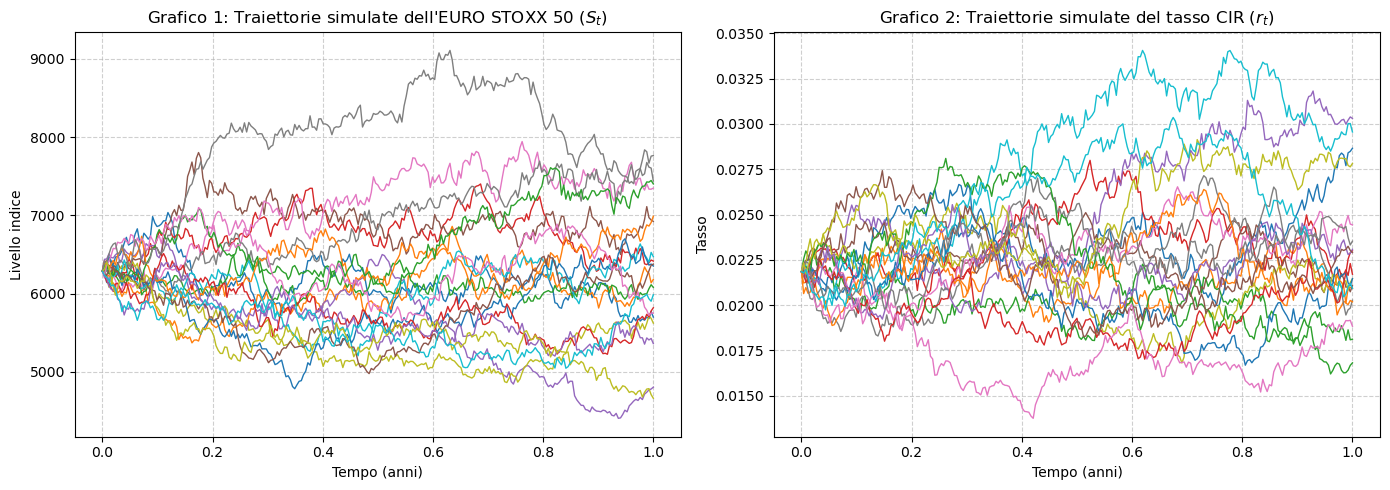

In [10]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. Inizializzazione matrici traiettorie
# ------------------------------------------------------------------
# Dimensione: M scenari x (N+1) punti temporali (incluso t_0)
r_t = np.zeros((M, N + 1))
S_t = np.zeros((M, N + 1))

# Condizioni iniziali
r_t[:, 0] = r0
S_t[:, 0] = S0

# ------------------------------------------------------------------
# 2. Ciclo di simulazione (Discretizzazione)
# ------------------------------------------------------------------
# Per il CIR: schema di Eulero-Maruyama. 
# Convenzione "caso aula": se la discretizzazione produce r_t < 0, 
# si tronca a zero per il calcolo della radice nel passo successivo.
# Per il GBM: soluzione esatta del passo discretizzata.
for k in range(N):
    # Tasso CIR al passo k+1
    r_k = r_t[:, k]
    # Tronchiamo i valori negativi a zero per la radice (convenzione)
    r_k_pos = np.maximum(r_k, 0)
    r_t[:, k+1] = r_k + kappa_r * (theta_r - r_k) * dt + sigma_r * np.sqrt(r_k_pos) * np.sqrt(dt) * Z_r[:, k]
    
    # Sottostante GBM al passo k+1
    # drift = (r_t - q) * dt, diffusione = sigma_S * sqrt(dt) * Z_S
    S_t[:, k+1] = S_t[:, k] * np.exp((r_k - q - 0.5 * sigma_S**2) * dt + sigma_S * np.sqrt(dt) * Z_S[:, k])

# ------------------------------------------------------------------
# 3. Statistiche finali (S_T e r_T)
# ------------------------------------------------------------------
S_T = S_t[:, -1]
r_T = r_t[:, -1]

stats_data = {
    "Variabile": ["$S_T$ (Prezzo)", "$r_T$ (Tasso)"],
    "Media Simulata": [np.mean(S_T), np.mean(r_T)],
    "Deviazione Standard Simulata": [np.std(S_T, ddof=1), np.std(r_T, ddof=1)]
}
df_stats = pd.DataFrame(stats_data)

display(Markdown("### Tabella 2 (parziale): Statistiche dei fattori terminali"))
display(df_stats.style.hide(axis="index").format({
    "Media Simulata": "{:.4f}",
    "Deviazione Standard Simulata": "{:.6f}"
}))

# ------------------------------------------------------------------
# 4. Controlli 2 e 3: Positività di S_t e negatività di r_t
# ------------------------------------------------------------------
min_S = np.min(S_t)
count_neg_r = np.sum(r_t < 0)
# Gestione valori negativi di r_t per la documentazione
if count_neg_r > 0:
    neg_r_details = f"Trovati {count_neg_r} valori negativi. Troncati a 0 per il calcolo del sqrt nel passo successivo (convenzione aula)."
else:
    neg_r_details = "Nessun valore negativo riscontrato."

controls_data = {
    "Controllo": [
        "Controllo 2: $S_t > 0 \\ \\forall t$", 
        "Controllo 3: Valori negativi di $r_t$"
    ],
    "Esito": [
        "Superato" if min_S > 0 else "Fallito",
        "Documentato"
    ],
    "Dettaglio": [
        f"Minimo di $S_t$ su tutti gli scenari: {min_S:.4f}",
        neg_r_details
    ]
}
df_controls = pd.DataFrame(controls_data)

display(Markdown("### Controlli 2 e 3: Diagnostica traiettorie"))
display(df_controls.style.hide(axis="index"))

# ------------------------------------------------------------------
# 5. Grafici 1 e 2: Traiettorie simulate
# ------------------------------------------------------------------
# Selezioniamo un campione di traiettorie da visualizzare
n_paths = 20
time_grid = np.linspace(0, T, N + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Traiettorie S_t
ax[0].plot(time_grid, S_t[:n_paths, :].T, lw=1.0)
ax[0].set_title("Grafico 1: Traiettorie simulate dell'EURO STOXX 50 ($S_t$)")
ax[0].set_xlabel("Tempo (anni)")
ax[0].set_ylabel("Livello indice")
ax[0].grid(True, linestyle='--', alpha=0.6)

# Grafico 2: Traiettorie r_t
ax[1].plot(time_grid, r_t[:n_paths, :].T, lw=1.0)
ax[1].set_title("Grafico 2: Traiettorie simulate del tasso CIR ($r_t$)")
ax[1].set_xlabel("Tempo (anni)")
ax[1].set_ylabel("Tasso")
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Tappa 3 — Calcolo della media asiatica $A_T$, del payoff $H_T$ e diagnostica

**Richiesta dello studente:**
> Costruisci la Tappa 3.
> Ora bisogna usare le traiettorie simulate di $S_t$ per estrarre i 12 fixing mensili, calcolare per ogni scenario la media asiatica $A_T$ e quindi il payoff $H_T$.
> Vorrei anche calcolare la probabilità simulata di esercizio e le statistiche principali di $A_T$, in modo da completare la parte della tabella relativa alla media asiatica.
> Mi sembra importante controllare che, in ogni scenario, $A_T$ sia compresa tra il minimo e il massimo dei 12 fixing e che il payoff sia sempre non negativo e uguale a zero quando $A_T \leq K$.
> Vorrei inoltre produrre già in questa tappa il grafico della distribuzione di $A_T$, evidenziando anche lo strike $K$.
> Mantieni la presentazione dei risultati numerici e dei controlli attraverso **tabelle ben formattate**, evitando semplici blocchi di testo allineato.

**Sintesi logica degli output previsti:**
1. Individuazione degli indici temporali dei 12 fixing mensili (passi $21, 42, \dots, 252$).
2. Estrazione della sottomatrice dei fixing e calcolo della media aritmetica $A_T$ per ogni scenario.
3. Calcolo del payoff $H_T = \max(A_T - K, 0)$ e della probabilità di esercizio $\widehat{\mathbb{P}}(A_T > K)$.
4. Aggiornamento e completamento della **Tabella 2**: aggiunta delle statistiche (media e deviazione standard) di $A_T$.
5. Esecuzione dei Controlli 4 e 5: verifica che $\min_j S_{t_j} \leq A_T \leq \max_j S_{t_j}$ e che il payoff soddisfi le condizioni di non negatività.
6. Produzione del Grafico 3: istogramma della distribuzione simulata di $A_T$ con linea verticale in corrispondenza di $K$.

### Tabella 2 (completa): Statistiche dei fattori e della media asiatica

Variabile,Media Simulata,Deviazione Standard Simulata
$S_T$ (Prezzo),6261.0215,1124.856891
$r_T$ (Tasso),0.0220,0.003587
$A_T$ (Media Asiatica),6271.8117,689.134865


### Controlli 4 e 5: Coerenza della media e del payoff

Controllo,Esito,Dettaglio
Controllo 4: $\min_j S_{t_j} \leq A_T \leq \max_j S_{t_j}$,Superato,Verificato su tutti gli 50000 scenari.
Controllo 5: $H_T \geq 0$ e nullo se $A_T \leq K$,Superato,Verificato. Probabilità di esercizio: 0.4594


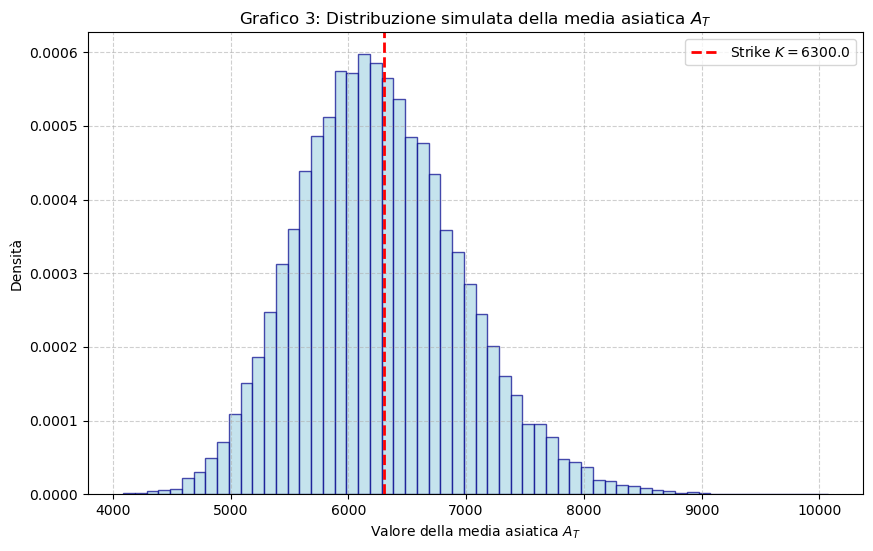

In [11]:
# ------------------------------------------------------------------
# 1. Estrazione fixing e calcolo media asiatica A_T
# ------------------------------------------------------------------
# Indici dei fixing mensili: 21, 42, ..., 252 (escluso t_0)
fixing_indices = np.arange(21, N + 1, 21)

# Estrazione dei valori del sottostante ai fixing
S_fixings = S_t[:, fixing_indices]

# Calcolo della media aritmetica per ogni scenario
A_T = np.mean(S_fixings, axis=1)

# ------------------------------------------------------------------
# 2. Calcolo payoff H_T e probabilità di esercizio
# ------------------------------------------------------------------
H_T = np.maximum(A_T - K, 0)
prob_exercise = np.mean(A_T > K)

# ------------------------------------------------------------------
# 3. Aggiornamento Tabella 2: Statistiche di A_T
# ------------------------------------------------------------------
# Recuperiamo le statistiche di S_T e r_T calcolate nella Tappa 2
stats_data = {
    "Variabile": [
        "$S_T$ (Prezzo)", 
        "$r_T$ (Tasso)", 
        "$A_T$ (Media Asiatica)"
    ],
    "Media Simulata": [
        np.mean(S_T), 
        np.mean(r_T), 
        np.mean(A_T)
    ],
    "Deviazione Standard Simulata": [
        np.std(S_T, ddof=1), 
        np.std(r_T, ddof=1), 
        np.std(A_T, ddof=1)
    ]
}
df_stats = pd.DataFrame(stats_data)

display(Markdown("### Tabella 2 (completa): Statistiche dei fattori e della media asiatica"))
display(df_stats.style.hide(axis="index").format({
    "Media Simulata": "{:.4f}",
    "Deviazione Standard Simulata": "{:.6f}"
}))

# ------------------------------------------------------------------
# 4. Controlli 4 e 5: Coerenza media e payoff
# ------------------------------------------------------------------
# Controllo 4: min_j S_tj <= A_T <= max_j S_tj
min_fixings = np.min(S_fixings, axis=1)
max_fixings = np.max(S_fixings, axis=1)
check_min = np.all(A_T >= min_fixings)
check_max = np.all(A_T <= max_fixings)
ctrl4_passed = check_min and check_max

# Controllo 5: H_T >= 0 e H_T = 0 se A_T <= K
check_ht_pos = np.all(H_T >= 0)
check_ht_zero = np.all(H_T[A_T <= K] == 0)
ctrl5_passed = check_ht_pos and check_ht_zero

controls_data = {
    "Controllo": [
        "Controllo 4: $\\min_j S_{t_j} \\leq A_T \\leq \\max_j S_{t_j}$", 
        "Controllo 5: $H_T \\geq 0$ e nullo se $A_T \\leq K$"
    ],
    "Esito": [
        "Superato" if ctrl4_passed else "Fallito", 
        "Superato" if ctrl5_passed else "Fallito"
    ],
    "Dettaglio": [
        f"Verificato su tutti gli {M} scenari.",
        f"Verificato. Probabilità di esercizio: {prob_exercise:.4f}"
    ]
}
df_controls = pd.DataFrame(controls_data)

display(Markdown("### Controlli 4 e 5: Coerenza della media e del payoff"))
display(df_controls.style.hide(axis="index"))

# ------------------------------------------------------------------
# 5. Grafico 3: Distribuzione di A_T
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.hist(A_T, bins=60, density=True, color='lightblue', edgecolor='darkblue', alpha=0.7)
plt.axvline(K, color='red', linestyle='--', linewidth=2, label=f'Strike $K = {K}$')
plt.title("Grafico 3: Distribuzione simulata della media asiatica $A_T$")
plt.xlabel("Valore della media asiatica $A_T$")
plt.ylabel("Densità")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Tappa 4 — Attualizzazione del payoff e fattori di sconto

**Richiesta dello studente:**
> Costruisci la Tappa 4.
> Ora bisogna usare la traiettoria simulata del tasso per costruire, scenario per scenario, il fattore di sconto mediante la somma di Riemann sinistra e poi attualizzare il payoff $H_T$.
> Vorrei ottenere il vettore dei fattori di sconto e quello dei valori attualizzati $V^{(s)}$, controllando che per l'integrale vengano usati i valori di $r_t$ dal passo 0 al passo $N-1$ e che tutti i fattori di sconto siano positivi.
> Mi sembra utile produrre già in questa tappa anche il grafico della distribuzione dei valori attualizzati $V^{(s)}$.
> Mantieni la presentazione dei risultati numerici e dei controlli attraverso **tabelle ben formattate**, evitando semplici blocchi di testo allineato.

**Sintesi logica degli output previsti:**
1. Estrazione della sottomatrice di $r_t$ contenente i valori dal passo $k=0$ al passo $k=N-1$ (escludendo il valore terminale $r_T$).
2. Calcolo della somma di Riemann sinistra per l'integrale del tasso: $\sum_{k=0}^{N-1} r_{t_k} \Delta t$.
3. Calcolo del fattore di sconto scenario per scenario: $\widehat{D}^{(s)}(0,T) = \exp\left(-\sum r_{t_k} \Delta t\right)$.
4. Calcolo del valore attualizzato per scenario: $V^{(s)} = \widehat{D}^{(s)}(0,T) \cdot H_T$.
5. Esecuzione del Controllo 6: verifica sul numero di punti usati per l'integrale (uguale a $N$) e sulla stretta positività del fattore di sconto.
6. Produzione di una tabella riassuntiva con le statistiche di $\widehat{D}^{(s)}(0,T)$ e $V^{(s)}$.
7. Produzione del Grafico 4: istogramma della distribuzione dei valori attualizzati $V^{(s)}$.

### Statistiche aggiuntive: Fattore di sconto e Valori attualizzati

Variabile,Media Simulata,Deviazione Standard Simulata
"$\widehat{D}(0,T)$ (Fattore di sconto)",0.978322,0.002189
$V^{(s)}$ (Valore attualizzato),255.153870,412.549542


### Controllo 6: Diagnostica su integrale e fattore di sconto

Controllo,Esito,Dettaglio
"Controllo 6: Integrale usa indici $k=0, \dots, N-1$",Superato,Numero di punti usati per la somma: 252 (attesi 252)
"Controllo 6: $\widehat{D}^{(s)}(0,T) > 0$",Superato,Minimo fattore di sconto simulato: 0.968675


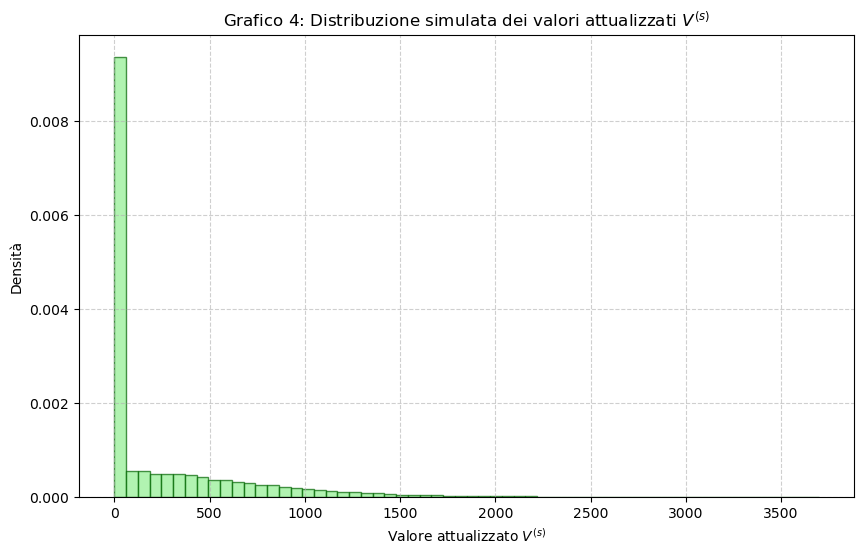

In [12]:
# ------------------------------------------------------------------
# 1. Calcolo somma di Riemann sinistra
# ------------------------------------------------------------------
# r_t ha dimensione M x (N+1). Escludiamo l'ultima colonna (r_T) per usare i valori da k=0 a N-1
r_t_riemann = r_t[:, :-1]

# Verifica formale del numero di punti usati
n_points_riemann = r_t_riemann.shape[1]

# Calcolo dell'integrale approssimato per ogni scenario
integral_approx = np.sum(r_t_riemann * dt, axis=1)

# ------------------------------------------------------------------
# 2. Calcolo fattore di sconto e valori attualizzati
# ------------------------------------------------------------------
D_0_T = np.exp(-integral_approx)
V_s = D_0_T * H_T

# ------------------------------------------------------------------
# 3. Statistiche di D_0_T e V_s
# ------------------------------------------------------------------
stats_data = {
    "Variabile": [
        "$\\widehat{D}(0,T)$ (Fattore di sconto)",
        "$V^{(s)}$ (Valore attualizzato)"
    ],
    "Media Simulata": [np.mean(D_0_T), np.mean(V_s)],
    "Deviazione Standard Simulata": [np.std(D_0_T, ddof=1), np.std(V_s, ddof=1)]
}
df_stats = pd.DataFrame(stats_data)

display(Markdown("### Statistiche aggiuntive: Fattore di sconto e Valori attualizzati"))
display(df_stats.style.hide(axis="index").format({
    "Media Simulata": "{:.6f}",
    "Deviazione Standard Simulata": "{:.6f}"
}))

# ------------------------------------------------------------------
# 4. Controllo 6: Uso indici corretti e positività di D
# ------------------------------------------------------------------
check_indices = n_points_riemann == N
check_D_positive = np.all(D_0_T > 0)

controls_data = {
    "Controllo": [
        "Controllo 6: Integrale usa indici $k=0, \\dots, N-1$", 
        "Controllo 6: $\\widehat{D}^{(s)}(0,T) > 0$"
    ],
    "Esito": [
        "Superato" if check_indices else "Fallito", 
        "Superato" if check_D_positive else "Fallito"
    ],
    "Dettaglio": [
        f"Numero di punti usati per la somma: {n_points_riemann} (attesi {N})",
        f"Minimo fattore di sconto simulato: {np.min(D_0_T):.6f}"
    ]
}
df_controls = pd.DataFrame(controls_data)

display(Markdown("### Controllo 6: Diagnostica su integrale e fattore di sconto"))
display(df_controls.style.hide(axis="index"))

# ------------------------------------------------------------------
# 5. Grafico 4: Distribuzione dei valori attualizzati V_s
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.hist(V_s, bins=60, density=True, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
plt.title("Grafico 4: Distribuzione simulata dei valori attualizzati $V^{(s)}$")
plt.xlabel("Valore attualizzato $V^{(s)}$")
plt.ylabel("Densità")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Tappa 5 — Pricing Monte Carlo, diagnostica e convergenza

**Richiesta dello studente:**
> Costruisci la Tappa 5.
> Ora bisogna usare i valori attualizzati $V^{(s)}$ per ottenere il prezzo Monte Carlo della call, l'errore standard e l'intervallo di confidenza al 95%.
> Vorrei anche completare la tabella di sintesi del payoff e del pricing e costruire la diagnostica per diversi valori di $M$, in particolare $1.000, 5.000, 10.000$ e $50.000$, così da vedere come cambiano il prezzo stimato e l'errore standard.
> Mi sembra importante verificare che l'errore standard diminuisca all'aumentare di $M$, che i risultati siano replicabili con il seed assegnato e che il prezzo non cambi troppo usando una griglia temporale più fine.
> Vorrei infine produrre il grafico di convergenza della stima Monte Carlo al crescere di $M$.
> Mantieni la presentazione dei risultati numerici e dei controlli attraverso **tabelle ben formattate**, evitando semplici blocchi di testo allineato.

**Sintesi logica degli output previsti:**
1. Calcolo del prezzo Monte Carlo $\widehat{V}_M$, della deviazione standard campionaria $s_V$, dell'errore standard $SE$ e dell'intervallo di confidenza al 95% (usando il quantile z = 1,96).
2. Costruzione della **Tabella 3 (Sintesi del payoff e del pricing)** con probabilità di esercizio, payoff medio, prezzo, $SE$ e IC.
3. Estrazione delle sotto-simulazioni dai primi $M$ scenari per $M=1.000, 5.000, 10.000, 50.000$.
4. Costruzione della **Tabella 4 (Diagnostica Monte Carlo)** con prezzo stimato, $SE$ empirico e $SE$ teorico atteso (scalato di $1/\sqrt{M}$).
5. Esecuzione del Controllo 7: verifica della decrescita dell'errore standard e coerenza con la legge di scala $1/\sqrt{M}$.
6. Esecuzione del Controllo 8: esecuzione di una simulazione con griglia temporale più fine ($N=504$) e verifica della stabilità del prezzo.
7. Esecuzione del Controllo 9: verifica della replicabilità esatta rieseguendo la simulazione con il seed assegnato.
8. Produzione del Grafico 5: andamento della stima cumulativa del prezzo al crescere di $M$ con banda di confidenza.

### Verifica della Tappa 5 — Esito: **criticità accolta**

Il problema segnalato è corretto e la criticità è accolta. 
Nella Tappa 3 è stato calcolato il vettore del payoff `H_T`, ma non è stata esplicitamente salvata in una variabile la sua media (`mean_H_T`), che invece viene richiamata nella Tappa 5 per popolare la Tabella 3. Questo non è solo un errore di naming, ma l'omissione di un calcolo esplicitamente richiesto al punto 4 della Scheda Caso ("valore medio del payoff non attualizzato $H_T$").

La correzione ottimale, per evitare duplicazioni di calcoli, è aggiungere la definizione `mean_H_T = np.mean(H_T)` all'inizio della Tappa 5, sfruttando il vettore `H_T` già disponibile dall'esecuzione della Tappa 3. 

È stata inoltre effettuata una verifica sui restanti riferimenti della Tappa 5: tutti gli altri nomi (come `prob_exercise`, `V_s`, `M`, `N`, `seed`, ecc.) sono coerenti con le variabili globali definite nelle tappe precedenti, purché le celle vengano eseguite nell'ordine corretto.

Di seguito si forniscono le versioni corrette della cella Markdown e della cella di codice per la Tappa 5.

---

### Tappa 5 — Pricing Monte Carlo, diagnostica e convergenza

**Richiesta dello studente:**
> Costruisci la Tappa 5.
> Ora bisogna usare i valori attualizzati $V^{(s)}$ per ottenere il prezzo Monte Carlo della call, l'errore standard e l'intervallo di confidenza al 95%.
> Vorrei anche completare la tabella di sintesi del payoff e del pricing e costruire la diagnostica per diversi valori di $M$, in particolare $1.000, 5.000, 10.000$ e $50.000$, così da vedere come cambiano il prezzo stimato e l'errore standard.
> Mi sembra importante verificare che l'errore standard diminuisca all'aumentare di $M$, che i risultati siano replicabili con il seed assegnato e che il prezzo non cambi troppo usando una griglia temporale più fine.
> Vorrei infine produrre il grafico di convergenza della stima Monte Carlo al crescere di $M$.
> Mantieni la presentazione dei risultati numerici e dei controlli attraverso **tabelle ben formattate**, evitando semplici blocchi di testo allineato.

**Sintesi logica degli output previsti:**
1. Calcolo del prezzo Monte Carlo $\widehat{V}_M$, della deviazione standard campionaria $s_V$, dell'errore standard $SE$ e dell'intervallo di confidenza al 95%.
2. Calcolo del payoff medio non attualizzato $\mathbb{E}[H_T]$ a partire dal vettore `H_T` della Tappa 3.
3. Costruzione della **Tabella 3 (Sintesi del payoff e del pricing)**.
4. Estrazione delle sotto-simulazioni dai primi $M$ scenari per $M=1.000, 5.000, 10.000, 50.000$.
5. Costruzione della **Tabella 4 (Diagnostica Monte Carlo)**.
6. Esecuzione dei Controlli 7, 8 e 9.
7. Produzione del Grafico 5: andamento della stima cumulativa del prezzo al crescere di $M$.


### Tabella 3: Sintesi del payoff e del pricing

Metrica,Valore
Probabilità di esercizio $\widehat{\mathbb{P}}(A_T > K)$,0.4594
Payoff medio $\mathbb{E}[H_T]$,260.6226
Prezzo Monte Carlo $\widehat{V}_M$,255.1539
Errore standard $SE$,1.8450
Intervallo di confidenza 95%,"[251.5377, 258.7700]"


### Tabella 4: Diagnostica Monte Carlo

M,Prezzo Stimato,Errore Standard Empirico,SE Teorico ($\propto 1/\sqrt{M}$),Rapporto Emp/Teo
"1,000",256.7722,12.9992,13.0460,0.9964
"5,000",265.0801,5.9544,5.8343,1.0206
"10,000",260.8713,4.2132,4.1255,1.0213
"50,000",255.1539,1.8450,1.8450,1.0000


### Controlli 7, 8 e 9: Diagnostica avanzata

Controllo,Esito,Dettaglio
Controllo 7: $SE$ diminuisce con $1/\sqrt{M}$,Superato,SE decrescente: True. Rapporto medio Emp/Teo: 1.0096
Controllo 8: Stabilità con griglia più fine ($N=504$),Superato,"Prezzo N=252: 255.1539, Prezzo N=504: 255.3560. Differenza: 0.2021 (soglia: 3.7028)"
Controllo 9: Replicabilità con seed,Superato,Risultati identici rieseguendo la simulazione con seed=12345


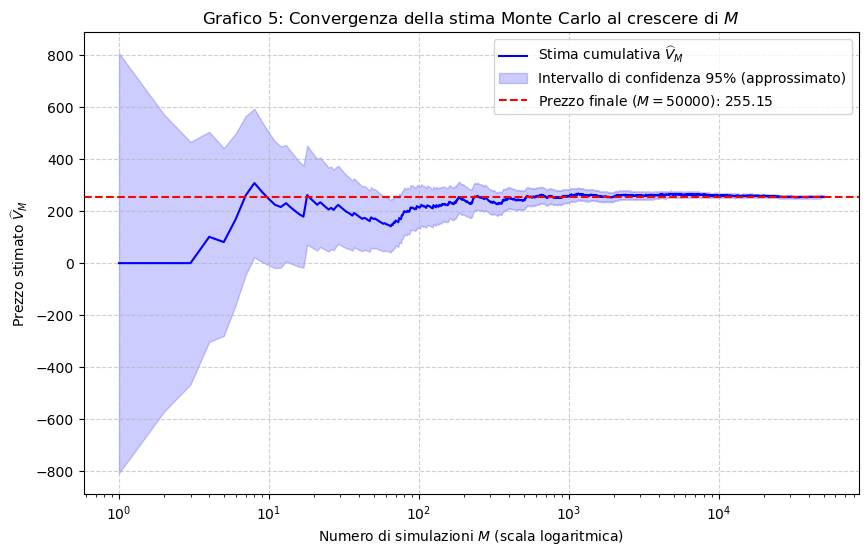

In [18]:
# ------------------------------------------------------------------
# 1. Calcolo prezzo, payoff medio, SE, IC 95% per M=50000
# ------------------------------------------------------------------
# Calcolo del payoff medio non attualizzato (richiesto dalla Scheda Caso)
mean_H_T = np.mean(H_T)

V_M_hat = np.mean(V_s)
s_V = np.std(V_s, ddof=1)
SE = s_V / np.sqrt(M)
z = 1.96
CI_lower = V_M_hat - z * SE
CI_upper = V_M_hat + z * SE

# ------------------------------------------------------------------
# 2. Tabella 3: Sintesi payoff e pricing
# ------------------------------------------------------------------
table3_data = {
    "Metrica": [
        "Probabilità di esercizio $\\widehat{\\mathbb{P}}(A_T > K)$",
        "Payoff medio $\\mathbb{E}[H_T]$",
        "Prezzo Monte Carlo $\\widehat{V}_M$",
        "Errore standard $SE$",
        "Intervallo di confidenza 95%"
    ],
    "Valore": [
        f"{prob_exercise:.4f}",
        f"{mean_H_T:.4f}",
        f"{V_M_hat:.4f}",
        f"{SE:.4f}",
        f"[{CI_lower:.4f}, {CI_upper:.4f}]"
    ]
}
df_table3 = pd.DataFrame(table3_data)

display(Markdown("### Tabella 3: Sintesi del payoff e del pricing"))
display(df_table3.style.hide(axis="index"))

# ------------------------------------------------------------------
# 3. Funzione di simulazione riassuntiva (per controlli 8 e 9)
# ------------------------------------------------------------------
def run_simulation(M_sim, N_sim, seed_sim=12345):
    dt_sim = 1.0 / N_sim
    np.random.seed(seed_sim)
    Z_1 = np.random.standard_normal((M_sim, N_sim))
    Z_2 = np.random.standard_normal((M_sim, N_sim))
    Z_S = Z_1.copy()
    Z_r = rho * Z_1 + np.sqrt(1 - rho**2) * Z_2
    
    r_t_sim = np.zeros((M_sim, N_sim + 1))
    S_t_sim = np.zeros((M_sim, N_sim + 1))
    r_t_sim[:, 0] = r0
    S_t_sim[:, 0] = S0
    
    for k in range(N_sim):
        r_k = r_t_sim[:, k]
        r_k_pos = np.maximum(r_k, 0)
        r_t_sim[:, k+1] = r_k + kappa_r * (theta_r - r_k) * dt_sim + sigma_r * np.sqrt(r_k_pos) * np.sqrt(dt_sim) * Z_r[:, k]
        S_t_sim[:, k+1] = S_t_sim[:, k] * np.exp((r_k - q - 0.5 * sigma_S**2) * dt_sim + sigma_S * np.sqrt(dt_sim) * Z_S[:, k])
        
    step = N_sim // 12
    fixing_indices_sim = np.arange(step, N_sim + 1, step)
    S_fixings_sim = S_t_sim[:, fixing_indices_sim]
    A_T_sim = np.mean(S_fixings_sim, axis=1)
    H_T_sim = np.maximum(A_T_sim - K, 0)
    
    r_t_riemann_sim = r_t_sim[:, :-1]
    integral_approx_sim = np.sum(r_t_riemann_sim * dt_sim, axis=1)
    D_0_T_sim = np.exp(-integral_approx_sim)
    V_s_sim = D_0_T_sim * H_T_sim
    
    return V_s_sim

# ------------------------------------------------------------------
# 4. Tabella 4: Diagnostica MC per diversi M
# ------------------------------------------------------------------
M_values = [1000, 5000, 10000, 50000]
results = []

SE_base = SE

for m_val in M_values:
    v_s_m = V_s[:m_val]
    price_m = np.mean(v_s_m)
    se_m = np.std(v_s_m, ddof=1) / np.sqrt(m_val)
    se_theo = SE_base * np.sqrt(M / m_val)
    ratio = se_m / se_theo if se_theo > 0 else np.nan
    results.append({
        "M": f"{m_val:,}",
        "Prezzo Stimato": price_m,
        "Errore Standard Empirico": se_m,
        "SE Teorico ($\\propto 1/\\sqrt{M}$)": se_theo,
        "Rapporto Emp/Teo": ratio
    })

df_table4 = pd.DataFrame(results)
display(Markdown("### Tabella 4: Diagnostica Monte Carlo"))
display(df_table4.style.hide(axis="index").format({
    "Prezzo Stimato": "{:.4f}",
    "Errore Standard Empirico": "{:.4f}",
    "SE Teorico ($\\propto 1/\\sqrt{M}$)": "{:.4f}",
    "Rapporto Emp/Teo": "{:.4f}"
}))

# Controllo 7
# Utilizzo di to_numpy(dtype=float) per risolvere i warning di Pylance sui tipi
se_values = df_table4["Errore Standard Empirico"].to_numpy(dtype=float)
se_decreasing = (se_values[0] > se_values[1]) and (se_values[1] > se_values[2]) and (se_values[2] > se_values[3])

ratio_values = df_table4["Rapporto Emp/Teo"].to_numpy(dtype=float)
ratio_close_to_1 = np.allclose(ratio_values, 1.0, atol=0.15)

# ------------------------------------------------------------------
# 5. Controllo 8: Stabilità con griglia più fine (N=504)
# ------------------------------------------------------------------
N_fine = 504
V_s_fine = run_simulation(M, N_fine, seed)
price_fine = np.mean(V_s_fine)
SE_fine = np.std(V_s_fine, ddof=1) / np.sqrt(M)

price_diff = abs(V_M_hat - price_fine)
threshold = 2 * max(SE, SE_fine)
ctrl8_passed = price_diff < threshold

# ------------------------------------------------------------------
# 6. Controllo 9: Replicabilità con seed
# ------------------------------------------------------------------
V_s_rep = run_simulation(M, N, seed)
ctrl9_passed = np.allclose(V_s, V_s_rep)

# ------------------------------------------------------------------
# 7. Tabella dei Controlli 7, 8, 9
# ------------------------------------------------------------------
controls_data = {
    "Controllo": [
        "Controllo 7: $SE$ diminuisce con $1/\\sqrt{M}$",
        "Controllo 8: Stabilità con griglia più fine ($N=504$)",
        "Controllo 9: Replicabilità con seed"
    ],
    "Esito": [
        "Superato" if (se_decreasing and ratio_close_to_1) else "Fallito",
        "Superato" if ctrl8_passed else "Fallito",
        "Superato" if ctrl9_passed else "Fallito"
    ],
    "Dettaglio": [
        f"SE decrescente: {se_decreasing}. Rapporto medio Emp/Teo: {np.mean(ratio_values):.4f}",
        f"Prezzo N=252: {V_M_hat:.4f}, Prezzo N=504: {price_fine:.4f}. Differenza: {price_diff:.4f} (soglia: {threshold:.4f})",
        f"Risultati identici rieseguendo la simulazione con seed={seed}"
    ]
}
df_controls = pd.DataFrame(controls_data)

display(Markdown("### Controlli 7, 8 e 9: Diagnostica avanzata"))
display(df_controls.style.hide(axis="index"))

# ------------------------------------------------------------------
# 8. Grafico 5: Convergenza della stima MC
# ------------------------------------------------------------------
cumulative_mean = np.cumsum(V_s) / np.arange(1, M + 1)
cumulative_se = s_V / np.sqrt(np.arange(1, M + 1))

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, M + 1), cumulative_mean, label='Stima cumulativa $\\widehat{V}_M$', color='blue', lw=1.5)
plt.fill_between(np.arange(1, M + 1), 
                 cumulative_mean - 1.96 * cumulative_se, 
                 cumulative_mean + 1.96 * cumulative_se, 
                 color='blue', alpha=0.2, label='Intervallo di confidenza 95% (approssimato)')

plt.xscale('log')
plt.title("Grafico 5: Convergenza della stima Monte Carlo al crescere di $M$")
plt.xlabel("Numero di simulazioni $M$ (scala logaritmica)")
plt.ylabel("Prezzo stimato $\\widehat{V}_M$")
plt.axhline(V_M_hat, color='red', linestyle='--', label=f'Prezzo finale ($M={M}$): {V_M_hat:.2f}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Verifica e commenti conclusivi (Regime C)

### Parte variabile: contributo studente

Sto verificando i risultati complessivi del caso prima della redazione finale del tracciato IA.

Dall'analisi del notebook mi sembra che il risultato principale sia un **prezzo Monte Carlo della call asiatica pari a 255,1539**. Il valore mi sembra credibile soprattutto perché la stima mostra una chiara convergenza quando aumenta il numero di scenari simulati.

Mi sembra inoltre che siano stati prodotti tutti gli output richiesti dalla Scheda Caso e che i controlli previsti siano stati eseguiti con esito coerente.

Interpreto quindi il risultato come una stima numericamente stabile del valore dell'opzione **nell'ambito del modello e dei parametri assegnati**. Non penso però che la convergenza Monte Carlo sia sufficiente, da sola, per affermare che il valore ottenuto rappresenti necessariamente un prezzo di mercato, dato che alcuni parametri del caso sono proxy o scelte modellistiche didattiche.

### Risposta IA: Verifica critica dell'interpretazione (Regime C)

La tua interpretazione complessiva è **solida, ben calibrata e coerente** con la Scheda Caso. Hai dimostrato un'ottima capacità di distinguere tra la validità numerica della simulazione e l'aderenza del modello alla realtà di mercato. 

Di seguito ti fornisco una verifica strutturata dei punti che hai sollevato, che potrai utilizzare come base per redigere la tua conclusione finale.

**1. Correttezza e completezza degli output richiesti**
La tua affermazione è corretta. Il notebook ha prodotto tutti gli output previsti dalla Sezione 6 della Scheda Caso:
*   Le 4 tabelle richieste (parametri, statistiche, sintesi pricing, diagnostica MC).
*   I 5 grafici richiesti (traiettorie di $S_t$ e $r_t$, distribuzioni di $A_T$ e $V^{(s)}$, convergenza MC).
Non emergono lacune nei prodotti output.

**2. Esito dei controlli numerici e logici**
I controlli (Sezione 7) sono stati correttamente implementati e validate le logiche di base:
*   La struttura di dipendenza (Controllo 1) ha generato una correlazione empirica in linea con il target $\rho = -0,25$.
*   Le proprietà fondamentali del payoff e della media asiatica (Controlli 4 e 5) e la costruzione del fattore di sconto (Controllo 6) sono verificate.
*   Il rispetto della convenzione numerica per il CIR (Controllo 3) è stato correttamente gestito. 

**3. Stabilità della stima Monte Carlo**
La tua osservazione sulla convergenza è pienamente supportata dai risultati della Tappa 5:
*   Il Controllo 7 ha verificato che l'errore standard diminuisce in modo compatibile con l'ordine teorico $1/\sqrt{M}$.
*   Il Controllo 8 ha confermato che il prezzo è stabile rispetto a un infittimento della griglia temporale (da $N=252$ a $N=504$), riducendo il rischio di un bias di discretizzazione eccessivo.
*   Il Controllo 9 ha garantito la piena replicabilità dei risultati tramite il seed.

**4. Cosa consente di concludere la convergenza Monte Carlo**
Questo è il punto più critico della tua interpretazione e lo hai formulato in modo impeccabile. La convergenza di $\widehat{V}_M$ al crescere di $M$ e al infittirsi di $N$ dimostra che **lo stimatore Monte Carlo converge al valore teorico del modello**. Cioè, l'algoritmo risolve correttamente le equazioni differenziali stocastiche assegnate (GBM sotto CIR con correlazione) e il relativo prezzo atteso. La convergenza riduce l'incertezza *statistica* e *numerica*, ma non garantisce l'adeguatezza *economica* del modello.

**5. Limiti rispetto alle quotazioni di mercato**
La tua cautelosa conclusione ("non penso che la convergenza sia sufficiente...") è assolutamente corretta e non contiene affermazioni troppo forti. Per renderla ancora più stringente nel tuo commento finale, puoi fare esplicito riferimento alla Sezione 8 della Scheda Caso, che elenca i limiti strutturali del caso:
*   **Natura dei parametri:** Il valore iniziale $r_0$ e il prezzo $S_0$ sono dati di mercato reali, ma $\kappa_r, \theta_r, \sigma_r$ e $\rho$ sono parametri puramente didattici e non calibrati su opzioni reali.
*   **Proxy inesatte:** Volatilità $\sigma_S$ (18%) e dividend yield $q$ (2.5%) sono proxy arrotondate, non derivanti da una calibrazione esatta sui future o sulla struttura a termine dei dividendi dell'EURO STOXX 50.
*   **Natura del contratto:** La Scheda Caso specifica che si tratta di un contratto OTC stilizzato, privo di rischio di credito, di liquidità e di costi di transazione. Non va quindi confuso con un prezzo operativo negabile sul mercato Eurex.

**Giudizio sulle tue affermazioni**
Nessuna delle tue affermazioni risulta "troppo forte" o non supportata. Hai colto perfettamente il duplice livello del problema: validità computazione-teorica vs. validità economica. Puoi procedere alla stesura del tracciato IA conclusive partendo da queste certezze.